# Assignment 6

<font size = "5">

Import the "pandas" and "matplotlib.pyplot" libraries (and any other libraries if you would like)

In [12]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



<font size = "5">

(a) Functions

<font size = "3">

- Read in the dataset named "features.csv".
- Create a ``` lambda ``` function that checks if weight $≤$ 3000
- Using the Pandas method ``.apply()``, create a new Series that shows ``True`` if weight $≤$ 3000 and ``False``if weight > 3000.
- ~~Using the ``.shape`` attribute, print the number of cars that have weight $≤$ 3000.~~
- Using Python commands, print the number of cars that have weight $\leq$ 3000.


**Note**: When I say "Using Python commands" that means you **should not** do either of the following:

```python
print(230)
```
```python
some_variable_name = 230
```

(Yes, you should get the number 230 if you did everything correctly)


In [4]:
# Write your answer here:
df = pd.read_csv("data/features.csv")

le_3000 = df["weight"].apply(lambda w: w <= 3000)

print(int(le_3000.sum()))

230


<font size = "5">

(b) Subsetting Data

<font size = "3" >

- Read in the dataset named "features.csv".
- Define a global variable called ```threshold``` that takes the <br>
value 2500
- Subset the data to get one dataset with weight $>$ threshold and <br>
another with weight $\le$ threshold. Use the ```.query()``` function.
- Compute the mean acceleration for each of these datasets, printing these values to the screen<br>

Note: Review how to define a global variable inside ```.query()```
 

In [6]:
# Write your answer here:

threshold = 2500

gt = df.query("weight > @threshold")
le = df.query("weight <= @threshold")

print(f"> {threshold} mean acceleration: {gt['acceleration'].mean():.3f}")
print(f"<= {threshold} mean acceleration: {le['acceleration'].mean():.3f}")

> 2500 mean acceleration: 15.000
<= 2500 mean acceleration: 16.539


<font size = "5">

(c) Use sorting + ".iloc[]"

<font size = "3">

- Read the "fifa23_players_basic.csv" dataset
- Use ".sort_values()" to order the "Age" column <br>
from oldest to youngest
- Get a subset with the 5 oldest players

In [9]:
# Write your answer here:
df = pd.read_csv("data/fifa23_players_basic.csv")

df_sorted = df.sort_values(by="Age", ascending=False)

oldest5 = df_sorted.head(5)
print(oldest5)


          Known As          Full Name  Overall  Potential  Value(in Euro)  \
592      G. Buffon   Gianluigi Buffon       79         79         1900000   
13548     S. Lukić       Stojan Lukić       62         62           45000   
3276    S. Torrico  Sebastián Torrico       72         72          250000   
15525  J. Szmatuła     Jakub Szmatuła       59         59           25000   
10851    M. Galezo      Moisés Galezo       64         64               0   

      Positions Played Best Position             Nationality  \
592                 GK            GK                   Italy   
13548               GK            GK  Bosnia and Herzegovina   
3276                GK            GK               Argentina   
15525               GK            GK                  Poland   
10851               CB            CB               Venezuela   

                                             Image Link  Age  ...  \
592    https://cdn.sofifa.net/players/001/179/23_60.png   44  ...   
13548  https:/

<font size = "5">

(d) Use queries + global variables

<font size = "3">

- Read the "fifa23_players_basic.csv" dataset
- Compute the mean of the column "Weight(in kg)"
and store it as a variable
- Subset the players whose Weight in kilograms is stricly large than this mean value
  using ".query()"


HINT: Remember that there is a special syntax for when using column names inside the .query() method (the backtick `)

In [11]:
# Write your answer here:

df["Weight(in kg)"] = pd.to_numeric(df["Weight(in kg)"], errors="coerce")

mean_weight = df["Weight(in kg)"].mean()
heavier = df.query("`Weight(in kg)` > @mean_weight")

print(mean_weight)
print(heavier)



75.17390366254922
                Known As                     Full Name  Overall  Potential  \
1             K. Benzema                 Karim Benzema       91         91   
2         R. Lewandowski            Robert Lewandowski       91         91   
6            T. Courtois              Thibaut Courtois       90         91   
7               M. Neuer                  Manuel Neuer       90         90   
8      Cristiano Ronaldo  C. Ronaldo dos Santos Aveiro       90         90   
...                  ...                           ...      ...        ...   
18492          H. Tiwari                Hrithik Tiwari       49         63   
18501      Deng Xiongtao                 Xiongtao Deng       48         61   
18507            M. Khan            Muheet Shabir Khan       48         61   
18508          L. Jongte            Lalbiakhlua Jongte       48         60   
18524         A. Brînzea                Andreș Brînzea       48         72   

       Value(in Euro) Positions Played Best P

<font size = "5">

(e) Plot by Category

<font size = "3">

Read in the dataset named "wdi_urban.csv".

  This contains data from 1980 and 2020.

- **Create an array with the unique values of "year" using the ``Pandas`` function ``unique``**

- **Create a plot with a ...**
    - Histogram of "prop_urbanpopulation" (proportion of urban population) for each year
    - Set the histogram option `alpha = 0.5` for transparency
    - All the histograms should be overlapping on the same plot
    - Create a legend with the list of years
    - Label the axes and the title

**Hint**: The procedure will be similar (but not exactly the same!) as when we created a scatter plot of cars with different numbers of cylinders in Lecture 11

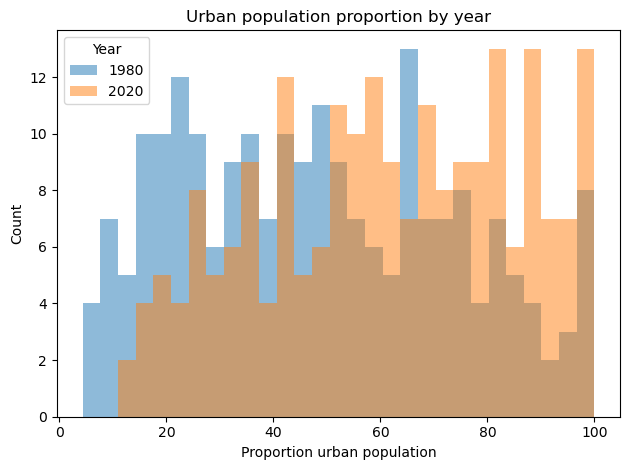

In [ ]:
# your answer here
df = pd.read_csv("data/wdi_urban.csv")
df["prop_urbanpopulation"] = pd.to_numeric(df["prop_urbanpopulation"], errors="coerce")

years = df["year"].unique()

vals = df["prop_urbanpopulation"].dropna()
bins = np.linspace(vals.min(), vals.max(), 30)

plt.figure()
for y in years:
    subset = df.loc[df["year"] == y, "prop_urbanpopulation"].dropna()
    plt.hist(subset, bins=bins, alpha=0.5, label=str(y))

plt.xlabel("Proportion urban population")
plt.ylabel("Count")
plt.title("Urban population proportion by year")
plt.legend(title="Year")
plt.tight_layout()
plt.show()